In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import lightgbm as lgb


In [27]:
model_path = '/export2/obasit/ClusterLevelServing/vllm_profiler_logs/latency_model/'

est_tp2_tp4 = lgb.Booster(model_file=model_path + "lightgbm_tp2_tp4/unified_latency_model_tp2_tp4.txt")
est_tp8 = lgb.Booster(model_file=model_path + "lightgbm_tp8/unified_latency_model_tp8.txt")

def infer(model, tp, freq, tokens_prefill=None, tokens_decode=None):
    inputs = np.array([
    np.log1p(len(tokens_prefill) if tokens_prefill else 0),
            np.log1p(sum(tokens_prefill) if tokens_prefill else 0),
            np.log1p(float(np.mean(tokens_prefill))) if tokens_prefill else 0,
            np.log1p(float(np.std(tokens_prefill)) if tokens_prefill else 0),
            np.log1p(len(tokens_decode) if tokens_decode else 0),
            np.log1p(sum(tokens_decode) if tokens_decode else 0),
            np.log1p(float(np.mean(tokens_decode))) if tokens_decode else 0,
            np.log1p(float(np.std(tokens_decode)) if tokens_decode else 0),
            tp,
            np.log1p(freq),
        ]).reshape(1, -1)

    # otherwise assume sklearn pipeline
    pred = np.exp(model.predict(inputs))
    return float(pred[0])

# Prefill

## TP2

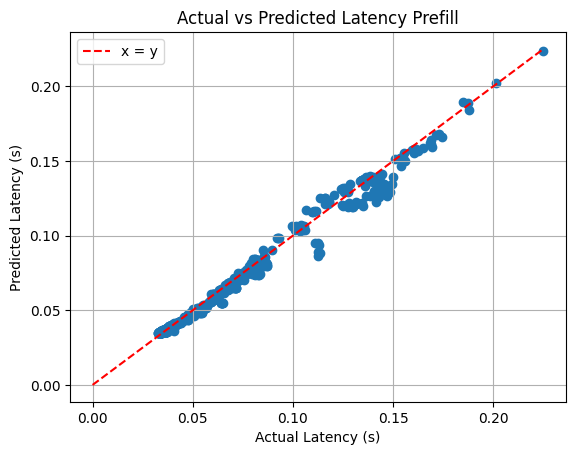

In [28]:
path = "/export1/liu3882/llm_energy/DistServe/my_script/eval_results_Oct12/tp2_logs_num1k/profiler_logs_seed1k_rps4_freq1080/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP2Prefill_1xTP2/default_log_path/prefill_0_Oct13031340/engine_0.csv"
df_prefill = pd.read_csv(path)


df_prefill['num_prompt_tokens_reqs_evald'] = df_prefill['num_prompt_tokens_reqs'].apply(eval)

# drop empty rows first
df_prefill = df_prefill[df_prefill['num_prompt_tokens_reqs_evald'].apply(lambda x: len(x) > 0)].copy()
# then do shift of gpu times
df_prefill.loc[:, "step_with_batch_queue_time_ms"] = df_prefill["step_with_batch_queue_time_ms_1_iters_delay"].shift(-1)

token_lists = df_prefill['num_prompt_tokens_reqs_evald'].tolist()
latency_lists = (df_prefill['step_with_batch_queue_time_ms'] / 1000.0).tolist()

predicted_latencies = [infer(est_tp2_tp4, tokens_prefill=tokens, tp=2, freq=1080) for tokens in token_lists]

plt.scatter(latency_lists, predicted_latencies)
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')
plt.legend()
plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency Prefill")
plt.grid(True)
plt.show()

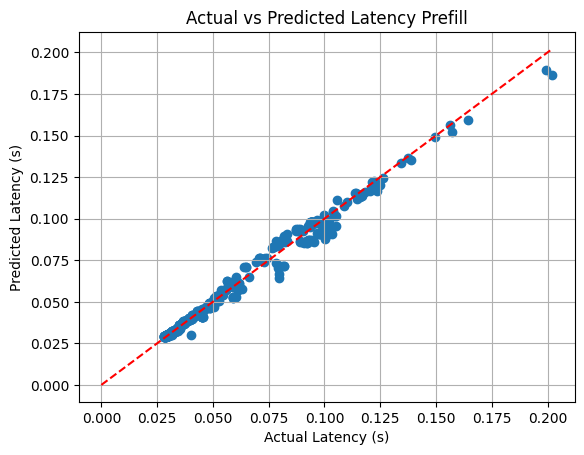

In [29]:
path = "/export1/liu3882/llm_energy/DistServe/my_script/eval_results_Oct12/tp2_logs_num1k/profiler_logs_seed1k_rps8_freq1980/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP2Prefill_1xTP2/default_log_path/prefill_0_Oct13022453/engine_0.csv"
df_prefill = pd.read_csv(path)


df_prefill['num_prompt_tokens_reqs_evald'] = df_prefill['num_prompt_tokens_reqs'].apply(eval)

# drop empty rows first
df_prefill = df_prefill[df_prefill['num_prompt_tokens_reqs_evald'].apply(lambda x: len(x) > 0)].copy()
# then do shift of gpu times
df_prefill.loc[:, "step_with_batch_queue_time_ms"] = df_prefill["step_with_batch_queue_time_ms_1_iters_delay"].shift(-1)

token_lists = df_prefill['num_prompt_tokens_reqs_evald'].tolist()
latency_lists = (df_prefill['step_with_batch_queue_time_ms'] / 1000.0).tolist()

predicted_latencies = [infer(est_tp2_tp4, tokens_prefill=tokens, tp=2, freq=1830) for tokens in token_lists]
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')
plt.scatter(latency_lists, predicted_latencies)
plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency Prefill")
plt.grid(True)
plt.show()

## TP4

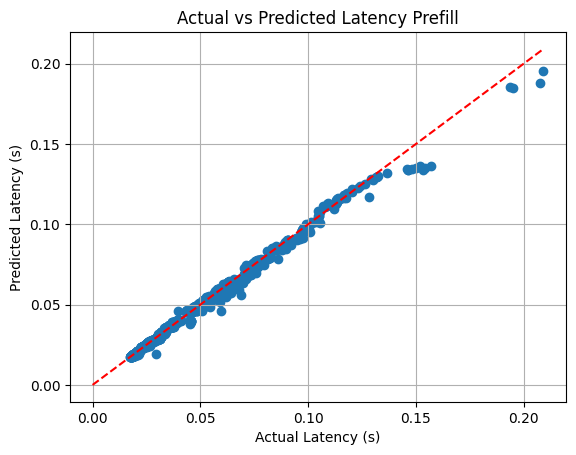

In [30]:
path = "/export1/liu3882/llm_energy/DistServe/my_script/eval_results_Oct12/tp4_logs_num4k/profiler_logs_seed1k_rps30_freq1980/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP4Prefill_1xTP4/default_log_path/prefill_0_Oct13034118/engine_0.csv"
df_prefill = pd.read_csv(path)


df_prefill['num_prompt_tokens_reqs_evald'] = df_prefill['num_prompt_tokens_reqs'].apply(eval)

# drop empty rows first
df_prefill = df_prefill[df_prefill['num_prompt_tokens_reqs_evald'].apply(lambda x: len(x) > 0)].copy()
# then do shift of gpu times
df_prefill.loc[:, "step_with_batch_queue_time_ms"] = df_prefill["step_with_batch_queue_time_ms_1_iters_delay"].shift(-1)

token_lists = df_prefill['num_prompt_tokens_reqs_evald'].tolist()
latency_lists = (df_prefill['step_with_batch_queue_time_ms'] / 1000.0).tolist()

predicted_latencies = [infer(est_tp2_tp4, tokens_prefill=tokens, tp=4, freq=1830) for tokens in token_lists]
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.scatter(latency_lists, predicted_latencies)
plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency Prefill")
plt.grid(True)
plt.show()

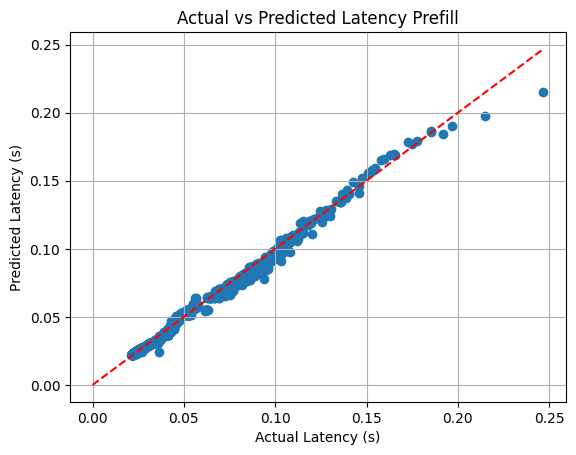

In [31]:
path = "/export1/liu3882/llm_energy/DistServe/my_script/eval_results_Oct12/tp4_logs_num4k/profiler_logs_seed1k_rps15_freq1080/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP4Prefill_1xTP4/default_log_path/prefill_0_Oct13041652/engine_0.csv"
df_prefill = pd.read_csv(path)


df_prefill['num_prompt_tokens_reqs_evald'] = df_prefill['num_prompt_tokens_reqs'].apply(eval)

# drop empty rows first
df_prefill = df_prefill[df_prefill['num_prompt_tokens_reqs_evald'].apply(lambda x: len(x) > 0)].copy()
# then do shift of gpu times
df_prefill.loc[:, "step_with_batch_queue_time_ms"] = df_prefill["step_with_batch_queue_time_ms_1_iters_delay"].shift(-1)

token_lists = df_prefill['num_prompt_tokens_reqs_evald'].tolist()
latency_lists = (df_prefill['step_with_batch_queue_time_ms'] / 1000.0).tolist()

predicted_latencies = [infer(est_tp2_tp4, tokens_prefill=tokens, tp=4, freq=1080) for tokens in token_lists]
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.scatter(latency_lists, predicted_latencies)
plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency Prefill")
plt.grid(True)
plt.show()

## TP8

# Decode

In [32]:
def decode_plot(data_list, tp, output_csv=None):
    all_latency_lists = []
    all_predicted_latencies = []
    inference_records = []
    test_counter = 0
    
    for df_decode, freq in data_list:
        df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
        df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 1 else np.nan)
        df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
        df_decode['max_num_generation_tokens_iter_evald'] = df_decode['max_num_generation_tokens_iter'].apply(eval)

        decode_token_lists = []
        latency_lists = []
        for row in df_decode.itertuples():
            if len(row.num_prompt_tokens_reqs_evald) == 0 or \
                len(row.max_num_generation_tokens_iter_evald) == 0 or \
                len(row.num_prompt_tokens_reqs_evald) != len(row.max_num_generation_tokens_iter_evald) or \
                pd.isna(row.iter_lat) or \
                len(row.num_prompt_tokens_reqs_evald) != row.num_running_reqs or \
                row.token_budget_used != len(row.num_prompt_tokens_reqs_evald) or \
                row.KV_usage_perc > 0.95:
                continue
            else:
                decode_lens = []
                
                for i, (prompt_len, gen_tok) in enumerate(zip(row.num_prompt_tokens_reqs_evald, row.max_num_generation_tokens_iter_evald)):
                    if gen_tok != 1:
                        # This is a decode request
                        # Total KV cache size = prompt_len + gen_tokens
                        decode_lens.append(prompt_len + gen_tok)
                if len(decode_lens) > 0:
                    decode_token_lists.append(decode_lens)
                    latency_lists.append(row.iter_lat)

        if tp in [2,4]:
            predicted_latencies = [infer(est_tp2_tp4, tokens_decode=decode_tokens, tp=tp, freq=freq) for decode_tokens in decode_token_lists]
        else:
            predicted_latencies = [infer(est_tp8, tokens_decode=decode_tokens, tp=tp, freq=freq) for decode_tokens in decode_token_lists]
        
        # Collect records for CSV
        for decode_tokens, actual_lat, pred_lat in zip(decode_token_lists, latency_lists, predicted_latencies):
            inference_records.append({
                'test_name': f'decode_test{test_counter}',
                'tp_size': tp,
                'frequency': freq,
                'avg_power_w': np.nan,  # Not available in this data
                'mean_latency': actual_lat,
                'num_prefill_reqs': 0,
                'sum_ctx_len': 0,
                'mean_ctx_len': 0.0,
                'std_ctx_len': 0.0,
                'num_decode_reqs': len(decode_tokens),
                'sum_decode_len': sum(decode_tokens),
                'mean_decode_len': np.mean(decode_tokens),
                'std_decode_len': np.std(decode_tokens),
                'predicted_latency': pred_lat
            })
            test_counter += 1
        
        all_latency_lists.extend(latency_lists)
        all_predicted_latencies.extend(predicted_latencies)
    
    # Save to CSV if output path provided
    if output_csv:
        df_output = pd.DataFrame(inference_records)
        df_output.to_csv(output_csv, index=False)
        print(f"Saved {len(inference_records)} records to {output_csv}")
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].scatter(all_latency_lists, all_predicted_latencies)
    axes[0].plot([0, max(all_latency_lists)], [0, max(all_latency_lists)], color='red', linestyle='--', label='x = y')
    axes[0].set_xlabel("Actual Latency (s)")
    axes[0].set_ylabel("Predicted Latency (s)")
    axes[0].set_title("Actual vs Predicted Latency decode")
    axes[0].grid(True)

    errors = np.array(all_predicted_latencies) - np.array(all_latency_lists)
    sorted_errors = np.sort(errors)
    cdf = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)

    axes[1].plot(sorted_errors, cdf)
    axes[1].set_xlabel("Error (s)")
    axes[1].set_ylabel("CDF")
    axes[1].set_title("CDF of Prediction Error")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

## TP2

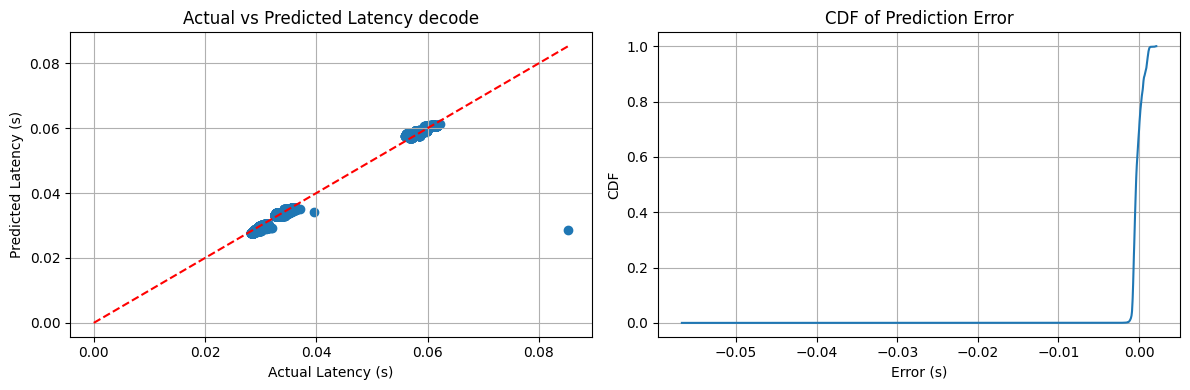

In [33]:
tp = 2

decode_plot([
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP2_360_1RPS/engine_0.csv"), 360),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP2_1080_2RPS/engine_0.csv"), 1080),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP2_1830_3RPS/engine_0.csv"), 1830),
            ],
            tp,
    # output_csv='decode_inference_results_tp2.csv',
    )


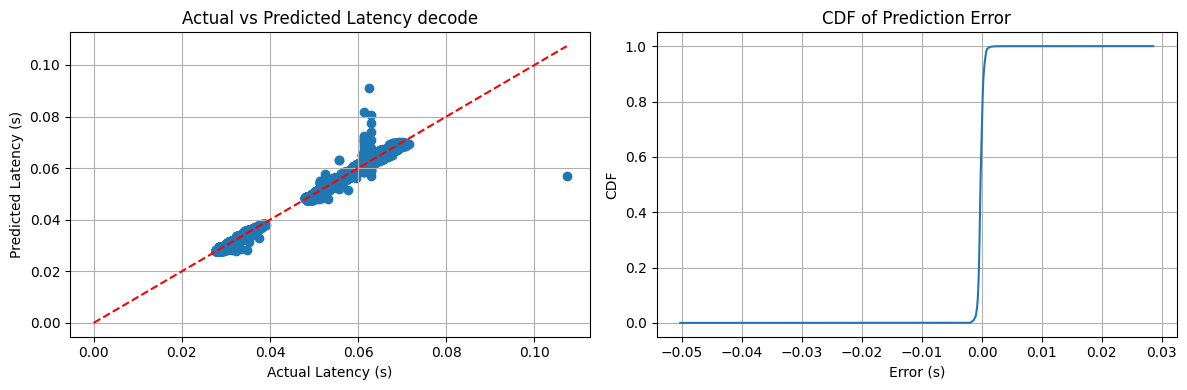

In [34]:
tp = 2

decode_plot([
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp2/360_20260217_163953/engine_0.csv"), 360),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp2/570_20260217_164247/engine_0.csv"), 570),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp2/780_20260217_172959/engine_0.csv"), 780),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp2/1080_20260217_164250/engine_0.csv"), 1080),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp2/1380_20260217_172210/engine_0.csv"), 1380),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp2/1680_20260217_164254/engine_0.csv"), 1680),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp2/1680_20260217_174311/engine_0.csv"), 1680),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp2/1830_20260217_173804/engine_0.csv"), 1830),
            ],
            tp,
    # output_csv='decode_inference_results_tp2.csv',
    )

## TP4

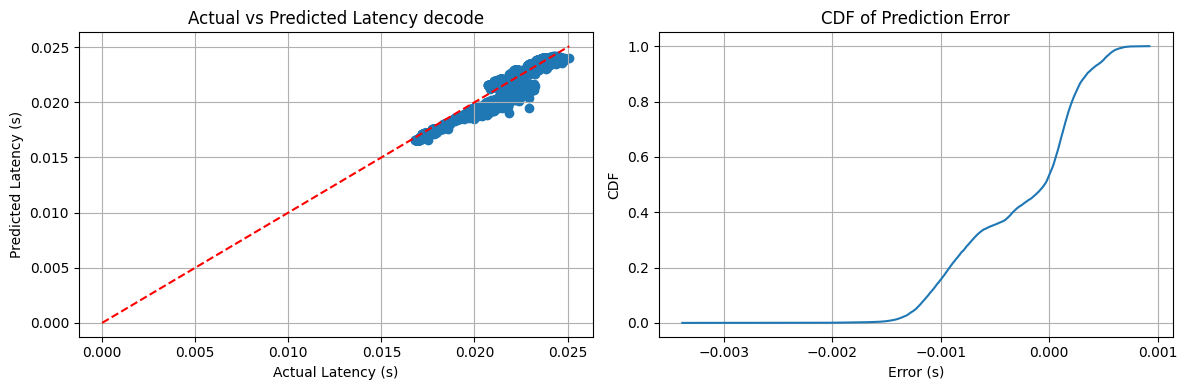

In [35]:
tp=4

decode_plot([
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP4_1080_7RPS/engine_0.csv"), 1080),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP4_1830_15RPS/engine_0.csv"), 1830),
            ],
            tp,
    # output_csv='decode_inference_results_tp4.csv',
    )


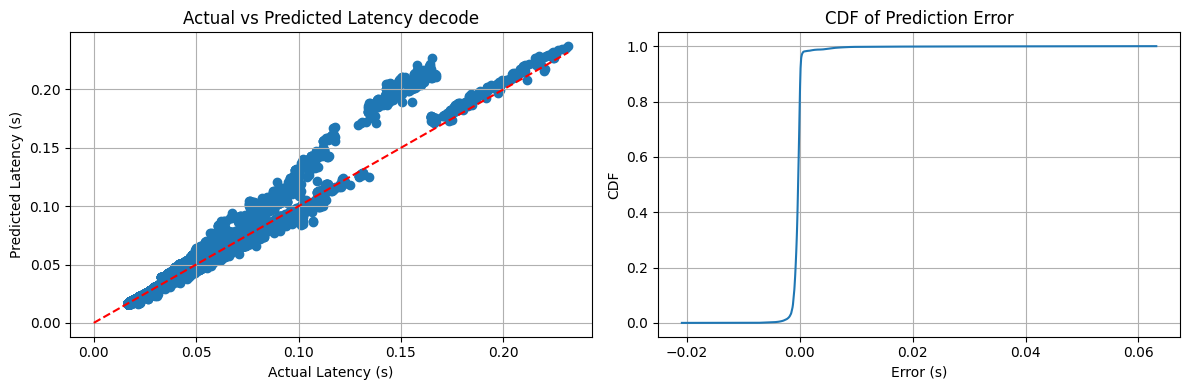

In [36]:
tp=4

decode_plot([
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp4/360_20260217_180029/engine_0.csv"), 360),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp4/570_20260217_185302/engine_0.csv"), 570),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp4/780_20260217_192040/engine_0.csv"), 780),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp4/1080_20260217_180032/engine_0.csv"), 1080),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp4/1080_20260217_185214/engine_0.csv"), 1080),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp4/1380_20260217_191301/engine_0.csv"), 1380),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp4/1380_20260217_195535/engine_0.csv"), 1380),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp4/1380_20260217_201659/engine_0.csv"), 1380),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp4/1680_20260217_195101/engine_0.csv"), 1680),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp4/1680_20260217_200346/engine_0.csv"), 1680),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp4/1680_20260217_202518/engine_0.csv"), 1630),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp4/1830_20260217_201149/engine_0.csv"), 1830),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp4/1830_20260217_202756/engine_0.csv"), 1830),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp4/1830_20260217_203956/engine_0.csv"), 1830),
            ],
            tp,
    # output_csv='decode_inference_results_tp4.csv',
    )


## TP8


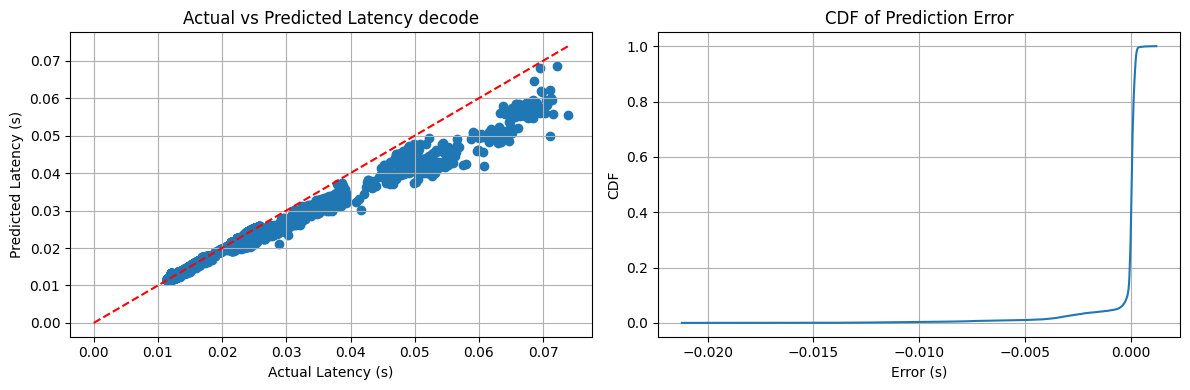

In [37]:
tp=8

decode_plot([
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP8_780_7RPS/engine_0.csv"), 780),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP8_1830_25RPS/engine_0.csv"), 1830),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP8_1830_45/engine_0.csv"), 1830),
            ],
            tp,
    # output_csv='decode_inference_results_tp8.csv',
    )

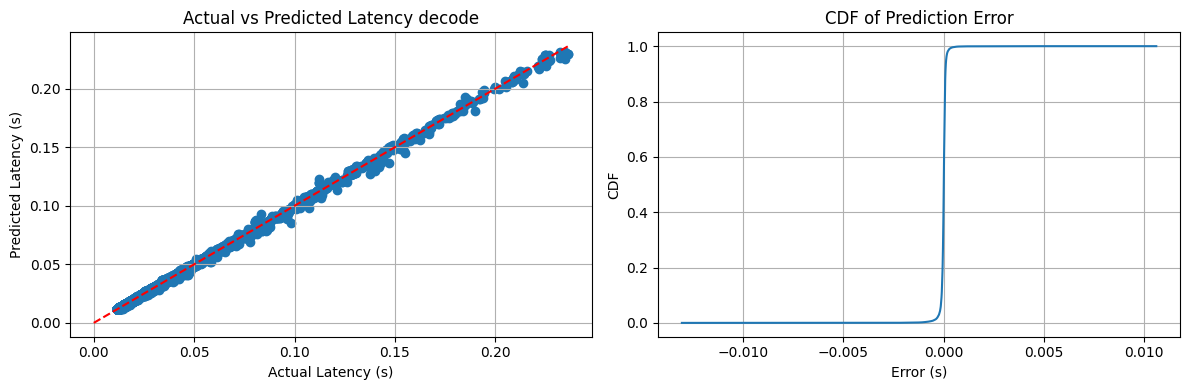

In [38]:
tp=8

decode_plot([
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp8/360_20260217_210527/engine_0.csv"), 360),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp8/570_20260217_213540/engine_0.csv"), 570),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp8/780_20260217_222013/engine_0.csv"), 780),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp8/780_20260217_222826/engine_0.csv"), 780),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp8/1080_20260217_225527/engine_0.csv"), 1080),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp8/1380_20260217_233429/engine_0.csv"), 1380),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp8/1680_20260218_001237/engine_0.csv"), 1680),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp8/1830_20260218_005026/engine_0.csv"), 1830),
            ],
            tp,
    # output_csv='decode_inference_results_tp8.csv',
    )

# Mixed

In [39]:
def hybrid_plot(data_list, tp, output_csv=None):
    all_latency_lists = []
    all_predicted_latencies = []
    inference_records = []
    test_counter = 0
    
    for df_decode, freq in data_list:
        df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
        df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 1 else np.nan)
        df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
        df_decode['max_num_generation_tokens_iter_evald'] = df_decode['max_num_generation_tokens_iter'].apply(eval)

        prefill_token_lists = []
        decode_token_lists = []
        latency_lists = []
        for row in df_decode.itertuples():
            if len(row.num_prompt_tokens_reqs_evald) == 0 or \
                len(row.max_num_generation_tokens_iter_evald) == 0 or \
                len(row.num_prompt_tokens_reqs_evald) != len(row.max_num_generation_tokens_iter_evald) or \
                pd.isna(row.iter_lat) or \
                len(row.num_prompt_tokens_reqs_evald) != row.num_running_reqs or \
                row.KV_usage_perc > 0.95:
                continue
            else:
                prefill_lens = []
                decode_lens = []
                
                for i, (prompt_len, gen_tok) in enumerate(zip(row.num_prompt_tokens_reqs_evald, row.max_num_generation_tokens_iter_evald)):
                    if gen_tok == 1:
                        # This is a prefill request
                        prefill_lens.append(prompt_len)
                    else:
                        # This is a decode request
                        # Total KV cache size = prompt_len + gen_tokens
                        decode_lens.append(prompt_len + gen_tok)
                if len(prefill_lens) > 0 and len(decode_lens) > 0:
                    prefill_token_lists.append(prefill_lens)
                    decode_token_lists.append(decode_lens)
                    latency_lists.append(row.iter_lat)

        if tp in [2,4]:
            predicted_latencies = [infer(est_tp2_tp4, tokens_prefill=prefill_tokens, tokens_decode=decode_tokens, tp=tp, freq=freq) for prefill_tokens, decode_tokens in zip(prefill_token_lists, decode_token_lists)]
        else:
            predicted_latencies = [infer(est_tp8, tokens_prefill=prefill_tokens, tokens_decode=decode_tokens, tp=tp, freq=freq) for prefill_tokens, decode_tokens in zip(prefill_token_lists, decode_token_lists)]
        
        # Collect records for CSV
        for prefill_tokens, decode_tokens, actual_lat, pred_lat in zip(prefill_token_lists, decode_token_lists, latency_lists, predicted_latencies):
            inference_records.append({
                'test_name': f'mixed_test{test_counter}',
                'tp_size': tp,
                'frequency': freq,
                'avg_power_w': np.nan,  # Not available in this data
                'mean_latency': actual_lat,
                'num_prefill_reqs': len(prefill_tokens),
                'sum_ctx_len': sum(prefill_tokens),
                'mean_ctx_len': np.mean(prefill_tokens),
                'std_ctx_len': np.std(prefill_tokens),
                'num_decode_reqs': len(decode_tokens),
                'sum_decode_len': sum(decode_tokens),
                'mean_decode_len': np.mean(decode_tokens),
                'std_decode_len': np.std(decode_tokens),
                'predicted_latency': pred_lat
            })
            test_counter += 1
        
        all_latency_lists.extend(latency_lists)
        all_predicted_latencies.extend(predicted_latencies)
    
    # Save to CSV if output path provided
    if output_csv:
        df_output = pd.DataFrame(inference_records)
        df_output.to_csv(output_csv, index=False)
        print(f"Saved {len(inference_records)} records to {output_csv}")
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].scatter(all_latency_lists, all_predicted_latencies)
    axes[0].plot([0, max(all_latency_lists)], [0, max(all_latency_lists)], color='red', linestyle='--', label='x = y')

    axes[0].set_xlabel("Actual Latency (s)")
    axes[0].set_ylabel("Predicted Latency (s)")
    axes[0].set_title("Actual vs Predicted Latency mixed")
    axes[0].grid(True)
    
    errors = np.array(all_predicted_latencies) - np.array(all_latency_lists)
    sorted_errors = np.sort(errors)
    cdf = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)

    axes[1].plot(sorted_errors, cdf)
    axes[1].set_xlabel("Error (s)")
    axes[1].set_ylabel("CDF")
    axes[1].set_title("CDF of Prediction Error")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

## TP2

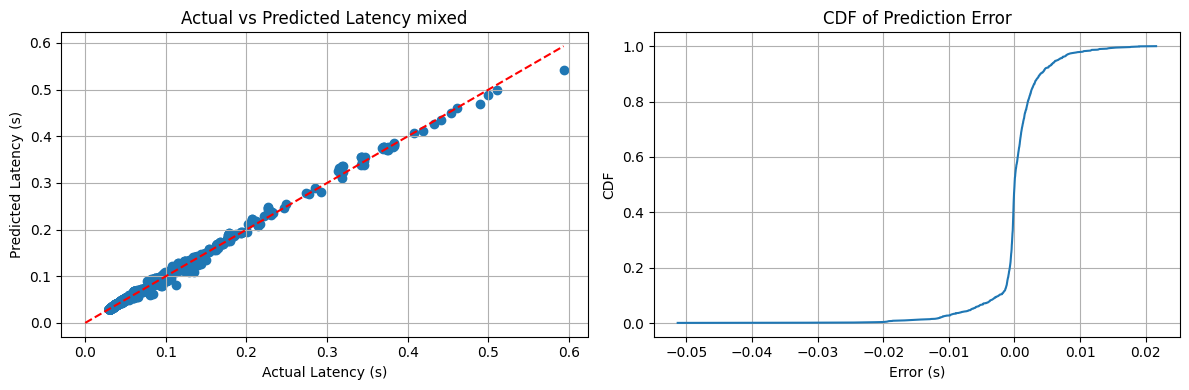

In [40]:
tp=2


hybrid_plot([
    (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP2_360_1RPS/engine_0.csv"), 360),
    (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP2_1080_2RPS/engine_0.csv"), 1080),
    (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP2_1830_3RPS/engine_0.csv"), 1830),
    ],
    tp,
    # output_csv='mixed_inference_results_tp2.csv',
    )  

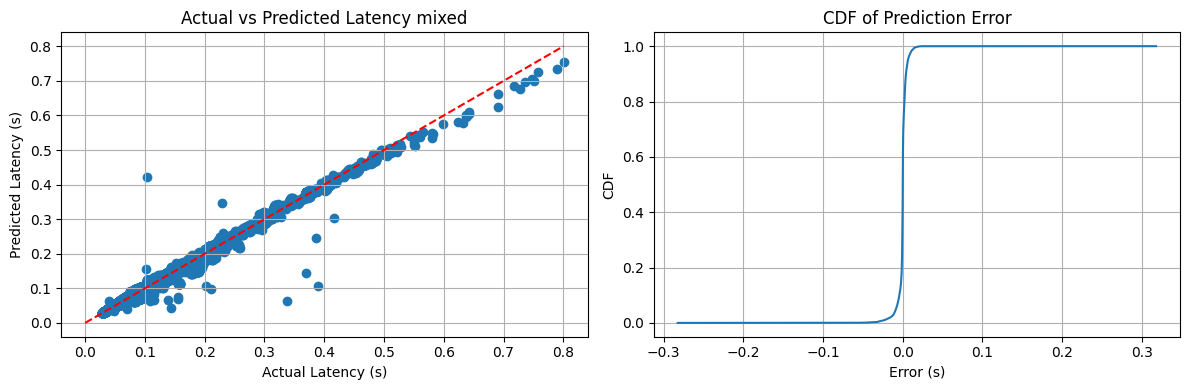

In [41]:
tp=2


hybrid_plot([
            (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp2/360_20260217_163953/engine_0.csv"), 360),
            (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp2/570_20260217_164247/engine_0.csv"), 570),
            (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp2/780_20260217_172959/engine_0.csv"), 780),
            (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp2/1080_20260217_164250/engine_0.csv"), 1080),
            (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp2/1380_20260217_172210/engine_0.csv"), 1380),
            (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp2/1680_20260217_164254/engine_0.csv"), 1680),
            (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp2/1680_20260217_174311/engine_0.csv"), 1680),
            (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp2/1830_20260217_173804/engine_0.csv"), 1830),
            ],
        tp,
        # output_csv='mixed_inference_results_tp2.csv',
        )  

## TP4

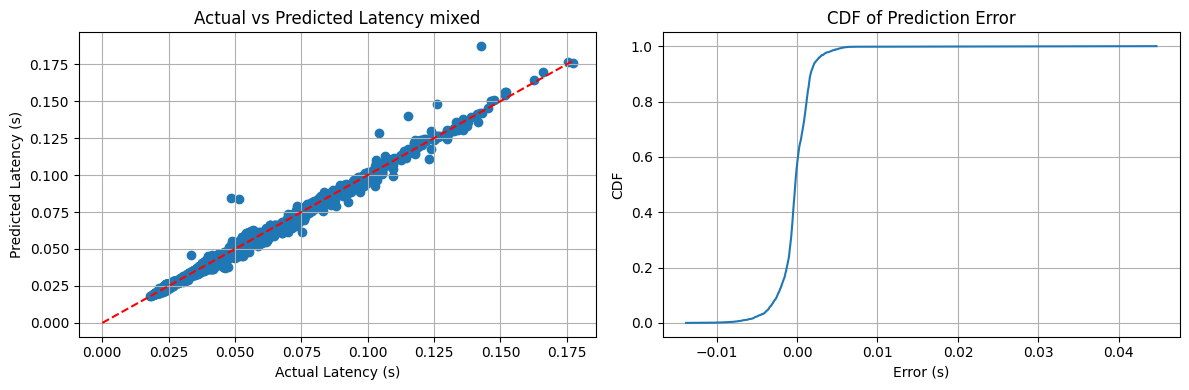

In [42]:
tp = 4

hybrid_plot([
    (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP4_1080_7RPS/engine_0.csv"), 1080),
    (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP4_1830_15RPS/engine_0.csv"), 1830),
    ],
    tp,
    # output_csv='mixed_inference_results_tp4.csv',
    )


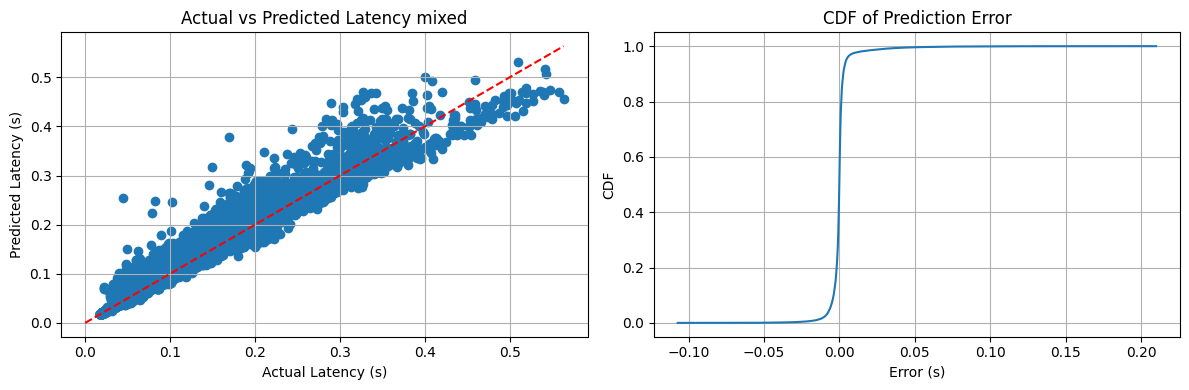

In [43]:
tp = 4

hybrid_plot([
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp4/360_20260217_180029/engine_0.csv"), 360),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp4/570_20260217_185302/engine_0.csv"), 570),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp4/780_20260217_192040/engine_0.csv"), 780),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp4/1080_20260217_180032/engine_0.csv"), 1080),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp4/1080_20260217_185214/engine_0.csv"), 1080),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp4/1380_20260217_191301/engine_0.csv"), 1380),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp4/1380_20260217_195535/engine_0.csv"), 1380),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp4/1380_20260217_201659/engine_0.csv"), 1380),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp4/1680_20260217_195101/engine_0.csv"), 1680),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp4/1680_20260217_200346/engine_0.csv"), 1680),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp4/1680_20260217_202518/engine_0.csv"), 1630),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp4/1830_20260217_201149/engine_0.csv"), 1830),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp4/1830_20260217_202756/engine_0.csv"), 1830),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp4/1830_20260217_203956/engine_0.csv"), 1830),
            ],
        tp,
        # output_csv='mixed_inference_results_tp4.csv',
        )


## TP8

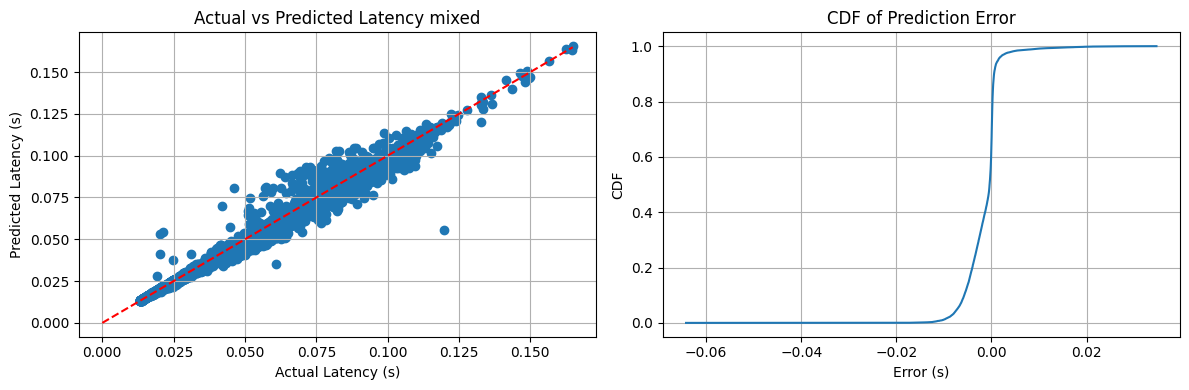

In [44]:
tp = 8

hybrid_plot([
    (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP8_780_7RPS/engine_0.csv"), 780),
    (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP8_1830_25RPS/engine_0.csv"), 1830),
    (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP8_1830_45/engine_0.csv"), 1830),
    ],
    tp,
    # output_csv='mixed_inference_results_tp8.csv',
    )


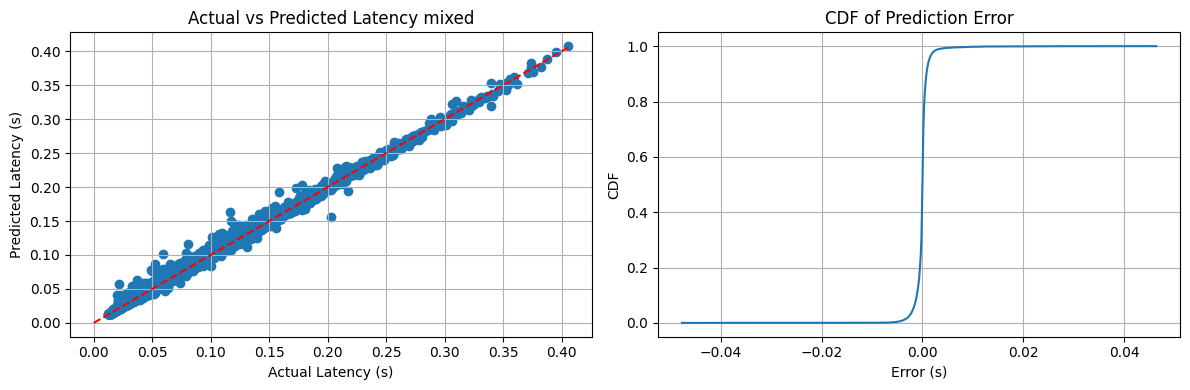

In [45]:
tp = 8

hybrid_plot([
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp8/360_20260217_210527/engine_0.csv"), 360),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp8/570_20260217_213540/engine_0.csv"), 570),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp8/780_20260217_222013/engine_0.csv"), 780),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp8/780_20260217_222826/engine_0.csv"), 780),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp8/1080_20260217_225527/engine_0.csv"), 1080),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp8/1380_20260217_233429/engine_0.csv"), 1380),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp8/1680_20260218_001237/engine_0.csv"), 1680),
                (pd.read_csv("/export2/obasit/ClusterLevelServing/vllm_profiler_logs/older_style_latency_only_profiling/tp8/1830_20260218_005026/engine_0.csv"), 1830),
            ],
        tp,
        # output_csv='mixed_inference_results_tp8.csv',
        )
